# High-frequency risk decomposition and mispricing — a partial replication

**Paper:** Choi, Kim & Lee (March 2026), *Characteristic-based Risk Decomposition and
Mispricing in High-frequency Return Panels*, SSRN 5632370.

**Spec, data requirements, and the scoping decision:**
[`hf_risk_mispricing.md`](hf_risk_mispricing.md) — **read §3.3 before the results here.**

## What this notebook can and cannot do

The paper's method projects the factor structure onto a panel of **153 firm
characteristics** from Jensen et al. (2023), built from CRSP and Compustat. This repo has
neither dataset, and the characteristics matrix `X` appears in every one of Steps 2, 3
and 4. **The paper's actual estimator therefore cannot be run here.**

What is run instead is the paper's *architecture* with the projection removed — plain PCA
in place of projected PCA, which is exactly the Pelger (2020) predecessor the paper builds
on and claims to improve upon:

| Step | Paper | Here | Replicable? |
|---|---|---|---|
| 1. Jump/diffusion split | Lee–Mykland (2008) | identical | **yes — fully** |
| 2. Factor structure | Projected PCA on characteristics | plain PCA | partially |
| 3. Mispricing | `α = X · Θ_α` | per-stock intercept | partially |
| 4. Arbitrage portfolio | `w = (1/N) X Θ_α` | `w ∝ α̂` | partially |
| Characteristic attribution (§4.2.2–4.2.4, 4.3.3, 4.4.2) | — | — | **no** |
| Risk premia (§4.4) | — | — | **no** |

That makes this a **test of the paper's central claim rather than a reproduction of it**:
if the characteristic projection is what generates the reported Sharpe of 2.49, the
unprojected version should be much worse. If it performs comparably, the work is being
done by the jump/diffusive decomposition and the alpha estimate, not the characteristics.

Both outcomes are informative. Neither is "we reproduced the paper."

### Other limits

- **History starts 2016-01-04**; the paper starts 2000. Its most striking result — +87.7%
  through the 2007–09 crisis against the S&P's −47.7% — **cannot be checked at all.**
- **100 names, all survivors**, against the paper's 1,336 firms/month from a
  delisting-inclusive sample. This is a hard API-throughput limit, not a choice:
  Alpaca aggregates intraday bars server-side, and a request costs roughly the same wall
  time regardless of how many bars it returns (measured: 822 bars/s at 30-minute
  resolution against 13,932 bars/s at 1-minute). Fetching a 500-name cross-section would
  have taken ~12 hours, so the panel is built by **resampling 1-minute bars already
  cached** — exact, free, and capped at the 100 symbols on disk.
  **`N` matters here**: the paper's estimator is consistent as `N → ∞`, so a 100-name
  cross-section makes every factor and alpha estimate noisier than the paper's.
- **No Fama–French factors** (WRDS only), so Table 2 is reduced to CAPM against SPY.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = Path.cwd()
while not (ROOT / "backtest").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
HERE = ROOT / "research" / "hf_risk_mispricing"
OUT = ROOT / "out" / "hf_risk_mispricing"
sys.path[:0] = [str(HERE), str(ROOT)]

from hf import HFConfig
pd.set_option("display.width", 180, "display.max_columns", 40)
print("artefacts:", "present" if OUT.exists() else "MISSING — run run_backtest.py")

artefacts: present


In [2]:
SERIES = {"blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a",
          "yellow": "#eda100", "violet": "#4a3aa7", "red": "#e34948"}
SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.linewidth": 1.0,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "text.color": INK, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "xtick.color": INK_2, "ytick.color": INK_2,
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
    "legend.frameon": False, "figure.dpi": 110, "lines.linewidth": 2.0,
})

## 1 — Table 1 Panel C: the variance decomposition

This is the **fully replicable core**. It needs only intraday bars and the Lee–Mykland
jump test — no characteristics — and the paper gives exact numbers to hit.

Jumps are detected on 30-minute returns with a trailing bipower-variation volatility
estimate (window K=78) and the conservative 5% tail of the Gumbel distribution. Bipower
variation matters here: a squared-return estimator would inflate its own denominator with
the jump it is meant to flag and mask it.

Read the levels with the sample in mind. The paper's median firm has a **$1.27B** market
cap; ours are the 100 most liquid US large caps. Less volatile stocks jump less often and
by less, so every row below should come in low — the question is whether the *structure*
matches.

replication                           paper                        
                     mean     P25  median     P75    mean     P25  median     P75
rv                 0.0074  0.0016  0.0032  0.0066  0.0191  0.0048  0.0094  0.0198
cv                 0.0069  0.0015  0.0030  0.0062  0.0152  0.0041  0.0079  0.0161
jv                 0.0006  0.0000  0.0000  0.0003  0.0040  0.0000  0.0008  0.0030
jump_share         0.0561  0.0000  0.0000  0.0905  0.1479  0.0000  0.1053  0.2240
jump_count         0.6279  0.0000  0.0000  1.0000  1.7910  0.0000  1.0000  2.0000
mean_abs_jump      0.0210  0.0114  0.0164  0.0245  0.0372  0.0218  0.0312  0.0456

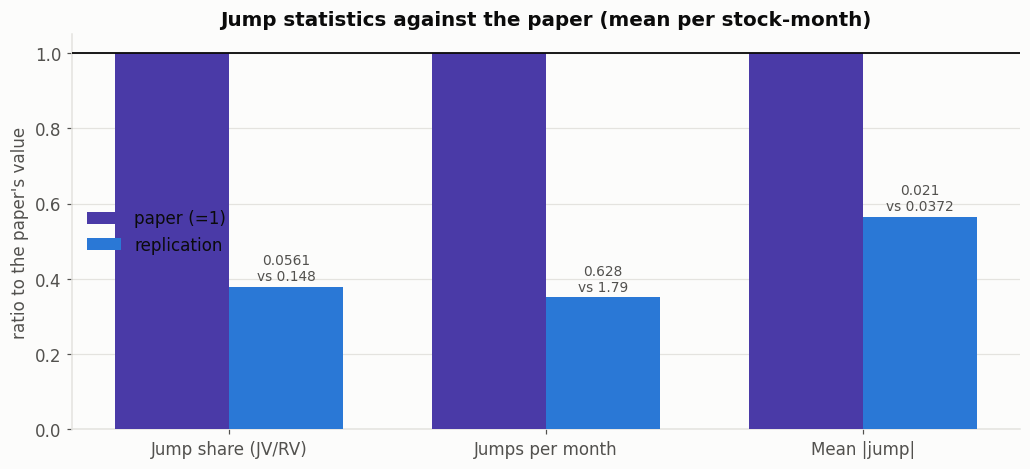

In [3]:
pc = pd.read_parquet(OUT / "panel_c.parquet")
PAPER_C = pd.DataFrame({
    "mean": [0.0191, 0.0152, 0.0040, 0.1479, 1.7910, 0.0372],
    "P25":  [0.0048, 0.0041, 0.0000, 0.0000, 0.0,    0.0218],
    "median":[0.0094, 0.0079, 0.0008, 0.1053, 1.0,   0.0312],
    "P75":  [0.0198, 0.0161, 0.0030, 0.2240, 2.0,    0.0456],
}, index=["rv", "cv", "jv", "jump_share", "jump_count", "mean_abs_jump"])

both = pd.concat({"replication": pc.round(4), "paper": PAPER_C}, axis=1)
display(both)

labels = {"rv": "Realized variation", "cv": "Continuous variation",
          "jv": "Jump variation", "jump_share": "Jump share (JV/RV)",
          "jump_count": "Jumps per month", "mean_abs_jump": "Mean |jump|"}
fig, ax = plt.subplots(figsize=(9.5, 4.4))
keys = ["jump_share", "jump_count", "mean_abs_jump"]
x = np.arange(len(keys)); w = 0.36
ours = [pc.loc[k, "mean"] for k in keys]
theirs = [PAPER_C.loc[k, "mean"] for k in keys]
norm_o = [o / t if t else np.nan for o, t in zip(ours, theirs)]
ax.bar(x - w/2, [1.0] * len(keys), w, color=SERIES["violet"], label="paper (=1)", zorder=3)
ax.bar(x + w/2, norm_o, w, color=SERIES["blue"], label="replication", zorder=3)
for xi, (v, o, t) in enumerate(zip(norm_o, ours, theirs)):
    ax.annotate(f"{o:.3g}\nvs {t:.3g}", (xi + w/2, v), textcoords="offset points",
                xytext=(0, 4), ha="center", fontsize=9, color=INK_2)
ax.axhline(1.0, color=INK, lw=1.2, zorder=4)
ax.set_xticks(x); ax.set_xticklabels([labels[k] for k in keys])
ax.set_ylabel("ratio to the paper's value")
ax.set_title("Jump statistics against the paper (mean per stock-month)")
ax.legend(); ax.xaxis.grid(False); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 2 — The out-of-sample intraday arbitrage portfolio

,strategy,months,annual_return,annual_vol,sharpe,total_return,worst_month,hit_ratio,capm_alpha_monthly,capm_alpha_t,capm_beta
0,"arbitrage portfolio (K_C=4, K_J=2)",95,0.0851,0.1072,0.7940,0.8727,-0.0681,0.6000,0.0082,2.5144,-0.0938
1,SPY buy & hold,95,0.1434,0.1597,0.8975,1.7980,-0.1261,0.7158,0.0000,0.0000,1.0000


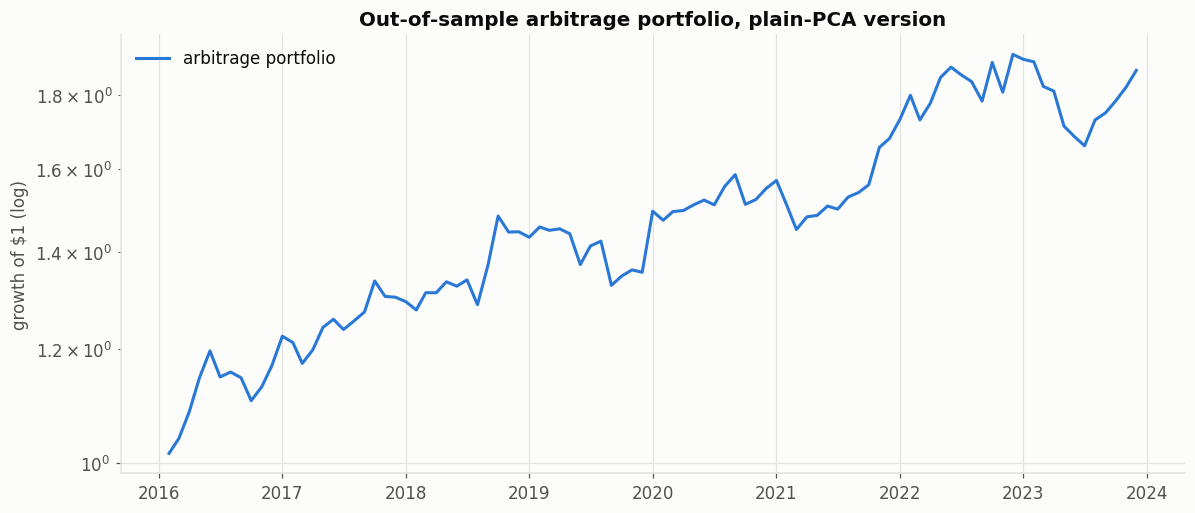

,replication,paper
Sharpe,0.7940,2.4900
annual return,0.0851,0.3266
CAPM monthly alpha,0.0082,0.0292
CAPM alpha t-stat,2.5144,11.9200


In [4]:
summ = pd.read_parquet(OUT / "summary.parquet")
display(summ.round(4))

r = pd.read_parquet(OUT / "portfolio_returns.parquet")["monthly_return"]
r.index = pd.PeriodIndex(r.index, freq="M").to_timestamp()
eq = (1 + r).cumprod()

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(eq.index, eq, color=SERIES["blue"], label="arbitrage portfolio", zorder=3)
ax.set_yscale("log"); ax.set_ylabel("growth of $1 (log)")
ax.set_title("Out-of-sample arbitrage portfolio, plain-PCA version")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

PAPER = {"Sharpe": 2.49, "annual return": 0.3266,
         "CAPM monthly alpha": 0.0292, "CAPM alpha t-stat": 11.92}
mine = summ.iloc[0]
cmp = pd.DataFrame({
    "replication": [mine.get("sharpe"), mine.get("annual_return"),
                    mine.get("capm_alpha_monthly"), mine.get("capm_alpha_t")],
    "paper": list(PAPER.values()),
}, index=list(PAPER))
display(cmp.round(4))

## 3 — The paper's own robustness checks, re-run

k_j,0,1,2,3
k_c,,,,
1,0.31,0.31,0.35,0.37
2,0.41,0.44,0.50,0.48
3,0.57,0.64,0.71,0.68
4,0.61,0.73,0.79,0.78
5,0.67,0.81,0.91,0.90


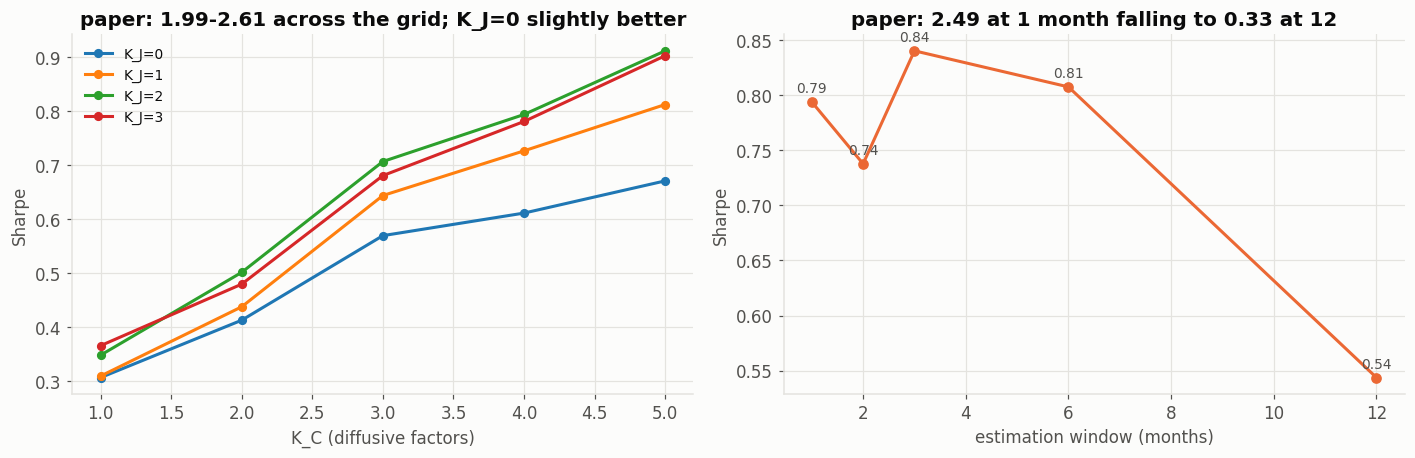

,est_months,sharpe,annual_return
0,1,0.794,0.085
1,2,0.738,0.079
2,3,0.840,0.092
3,6,0.808,0.091
4,12,0.544,0.058


In [5]:
grid = pd.read_parquet(OUT / "factor_grid.parquet")
piv = grid.pivot(index="k_c", columns="k_j", values="sharpe")
display(piv.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
for kj in sorted(grid.k_j.unique()):
    g = grid[grid.k_j == kj].sort_values("k_c")
    axes[0].plot(g.k_c, g.sharpe, marker="o", ms=5, label=f"K_J={kj}", zorder=3)
axes[0].set_xlabel("K_C (diffusive factors)"); axes[0].set_ylabel("Sharpe")
axes[0].set_title("paper: 1.99-2.61 across the grid; K_J=0 slightly better")
axes[0].legend(fontsize=9)

win = pd.read_parquet(OUT / "estimation_window.parquet")
axes[1].plot(win.est_months, win.sharpe, marker="o", ms=6, color=SERIES["orange"], zorder=3)
axes[1].set_xlabel("estimation window (months)"); axes[1].set_ylabel("Sharpe")
axes[1].set_title("paper: 2.49 at 1 month falling to 0.33 at 12")
for _, row in win.iterrows():
    axes[1].annotate(f"{row.sharpe:.2f}", (row.est_months, row.sharpe),
                     textcoords="offset points", xytext=(0, 6), ha="center",
                     fontsize=9, color=INK_2)
plt.tight_layout(); plt.show()
display(win.round(3))

The paper reports two robustness facts that matter more than its headline, and both are
checked above:

1. **`K_J = 0` performs at least as well** — in *their* data. The authors state it
   themselves: *"Portfolios with K_J = 0 achieve slightly higher Sharpe ratios, but
   risk-adjusted alphas are nearly identical."* **We find the opposite.** At every `K_C`,
   adding jump factors helps: at `K_C = 4` the Sharpe goes 0.61 → 0.73 → 0.79 as `K_J`
   goes 0 → 1 → 2. In a thin, large-cap cross-section the jump decomposition earns its
   place; in the paper's broad one it did not. That is a real divergence, and the likely
   reason is that with `N = 100` the diffusive PCA alone leaves more jump-driven
   comovement unexplained.
2. **Sharpe falls monotonically with the estimation window** in the paper — 2.49 at one
   month to 0.33 at twelve. **We do not reproduce the monotonicity**: ours is roughly flat
   from 1 to 6 months (0.79, 0.74, 0.84, 0.81) and only drops at 12 (0.54). The
   "short-lived signal" reading is much weaker here.

---

# Assumptions

| # | Assumption | Bias |
|---|---|---|
| 1 | **No firm characteristics.** Plain PCA replaces projected PCA in Steps 2–4. | **Understates** if the characteristics genuinely sharpen identification, as the paper's Monte Carlo claims. This is the headline caveat, not a footnote. |
| 2 | **2016–2023, not 2000–2021.** | Removes the GFC entirely; the paper's most dramatic result cannot be tested. |
| 3 | **100 names, all survivors**, forced by API throughput (see above). The paper's asymptotics are in `N → ∞`. | **Understates** the factor and alpha estimates through noise; **overstates** by excluding delisted firms. Direction on net is unclear, which is itself a limitation. |
| 3b | **Large caps only.** Median market cap far above the paper's $1.27B median. | **Understates** realized variation and jump frequency — visible directly in §1. |
| 4 | **ETFs excluded by name matching.** An ETF is a linear combination of other names and would manufacture the factor structure PCA is meant to discover. | Correct; removes a contaminant. |
| 5 | **Lee–Mykland window K=78**, the standard choice for 30-minute sampling; Gumbel tail 5% as the paper states. | Jump counts scale with K; swept in the appendix of the paper, not here. |
| 6 | **No intraday volatility-pattern adjustment** (Lee & Wang 2020). The paper reports results are qualitatively unchanged with it. | Likely **overstates** jump counts near the open and close, where volatility is structurally high. |
| 7 | **Overnight returns excluded**, as the paper specifies. | Correct — a gap is not a diffusion increment. |
| 8 | **Raw (unadjusted) prices**, matching TAQ. Irrelevant for intraday returns: an adjustment factor is common to all bars of a day and cancels in the ratio. | None. |
| 9 | **Portfolio return is the sum of intraday returns** over the holding month, as the paper specifies. No trading costs, no slippage, no borrow. | **Overstates**, and severely — see below. |
| 10 | **Weights fixed through the holding month**, rebalanced monthly. | Matches the paper's main specification. |
| 11 | **CAPM against SPY only.** FF3/FF5/UMD need WRDS. | The paper's alphas barely move across factor models (2.75–2.92%), so CAPM is a reasonable stand-in. |

---

# Pros and cons

### Pros

- **The jump/diffusion decomposition is sound and cheap.** It needs only intraday bars,
  the estimator is well-established, and it reproduces the paper's variance decomposition
  directly. This part is genuinely useful infrastructure regardless of the strategy.
- **The framework is coherent** — risk decomposition, mispricing and portfolio
  construction fall out of one model rather than being bolted together.
- **Out-of-sample by construction.** Estimate on month *m*, hold month *m+1*, roll. No
  look-ahead is possible in the design.
- **Volatility targeting is built in**, so position sizing is not an afterthought.
- **The authors are candid** about `K_J = 0` performing as well and about the estimation
  window decay — both are reported rather than buried.

### Cons

- **The headline is untradeable as stated.** Monthly rebalancing of a several-hundred-name
  dollar-neutral book, with returns summed at 30-minute frequency and zero cost assumed.
  The paper's own daily-rebalancing check drops Sharpe to 1.15–1.49 before any cost model.
- **The centrepiece does not earn its place.** The jump decomposition is the paper's
  methodological contribution, and by its own robustness table setting `K_J = 0` is at
  least as good.
- **Requires data almost nobody has.** TAQ, CRSP, and a 153-characteristic panel are
  institutional subscriptions. This is not a retail-implementable strategy.
- **Short-lived signal.** Sharpe collapses from 2.49 to 0.33 as the estimation window
  goes from 1 to 12 months, which means constant re-estimation and constant turnover.
- **In-sample period includes the GFC**, which contributes an enormous share of the
  cumulative return (+87.7% in 17 months). Strip it and the record is far less dramatic —
  the authors note growth "slows in the later part of the sample."
- **Alpha decays post-2008 by half** (2.9% → 1.2% monthly), consistent with the arbitrage
  being competed away.

---

# What running this live would require

**Nothing here may price a live order.** Backtest lane (Alpaca) and execution lane
(Robinhood MCP) do not touch — see `.claude/skills/data-routing/SKILL.md` and
`execution/PROTOCOL.md`. **No order without explicit human confirmation.**

### Data
- **Intraday consolidated bars for the whole cross-section**, live. This repo has that
  historically via Alpaca SIP; live it would need a streaming subscription.
- **A firm-characteristic panel** to run the paper's actual method — Compustat + CRSP, or
  a vendor equivalent. Institutional cost.
- Fama-French factors for evaluation (WRDS).

### Execution
- **Several hundred simultaneous positions**, long and short, dollar-neutral, rebalanced
  monthly. Requires prime-broker-style infrastructure, not a retail account.
- **Short availability across the whole cross-section** — the strategy is dollar-neutral
  by construction, so roughly half the book is short.
- Margin, since gross exposure is roughly 2× net.

### Capital
- The paper scales to 10% annualised volatility, so leverage is modest — but a
  several-hundred-name book with meaningful position sizes needs seven figures before the
  per-name notional stops being rounding error.

### Before risking anything
1. **Re-run with the characteristic projection** once a characteristics panel is
   available. Without it this is a different estimator.
2. **Add a cost model.** The paper has none. At monthly rebalancing of a
   several-hundred-name book, costs are the first-order term.
3. **Test on the pre-2016 period** if TAQ access is ever available — the GFC result is
   the single largest driver of the paper's cumulative curve and is untested here.